# Importing Libraries

In [95]:
import pandas as pd
import numpy as np

import geopandas as gpd
import folium
from folium.plugins import HeatMap
import pydeck as pdk
import hashlib


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from shapely import wkt

# Loading DF

In [96]:
pre_pca_df_final = pd.read_csv('Data\\display_rdy_data_4.csv', low_memory=False)
df_pca_final = pd.read_csv('Data\\clus_rdy_data_5.csv', low_memory=False)


# Clustering DBSCAN

A rule proposed by the author of the algorithim is to set the min_samples to = num of dimension + 1 ( 14 in our case ).

But while running the DBSCAN we couldn't get more than 1 cluster doesn't matter which eps we chose, this can be explained by the amount of samples we have ( only 245 incident zips which is not a lot ).

In [97]:
# Test run DBSCAN on random hyperparams
# Generate random values
eps_rnd = np.random.uniform(0.5, 10.0)
min_samples_rnd = np.random.randint(1,14)

db = DBSCAN(eps = eps_rnd, min_samples = min_samples_rnd).fit(df_pca_final.drop("Incident_Zip",axis = 1))
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"EPS: {eps_rnd:.2f} , min_samples: {min_samples_rnd}")
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

EPS: 7.65 , min_samples: 11
Estimated number of clusters: 1
Estimated number of noise points: 10


After some brief testing we found out that the rule proposed by the author didn't suite our data.

so we chose to use min_samples = 3 since it got the least amount of noise points in the test run. Now we need to find the best value for the eps hyperparameter.

we will do it using the KNN algo with k=3 ( not for predicting but for measuring the distance and finding the best eps for the specific min_samples using the elbow method ).

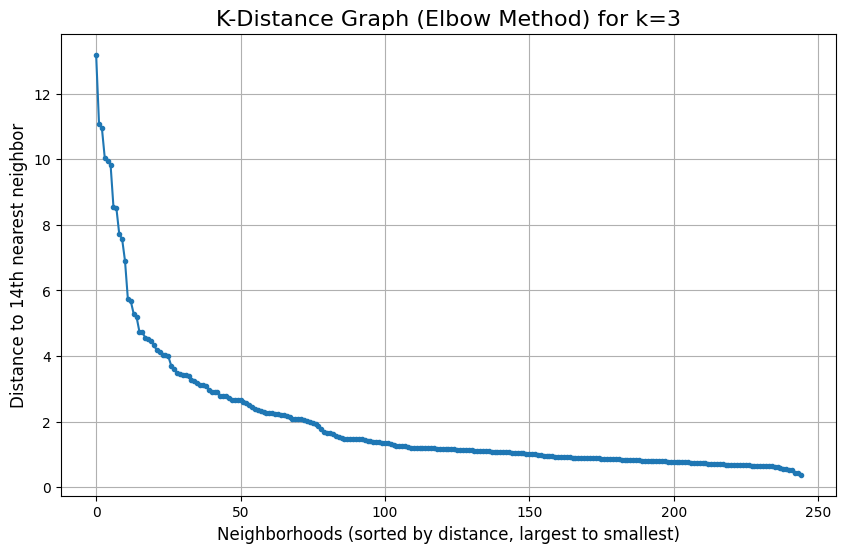

In [98]:
# k is 63 based on the min_samples we chose
k = 3
X_pca = df_pca_final.drop("Incident_Zip", axis=1).values

# Fit the algorithm on our 13 PCA data
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_pca)

# Calculate distances
distances, indices = neighbors_fit.kneighbors(X_pca)

# Extract the distance to the 6th neighbor ( most distant neighbor of the 3 )
k_distances = distances[:, k-1]

# FLIP THE GRAPH: Sort the distances in descending order using [::-1]
k_distances_sorted_desc = np.sort(k_distances)[::-1]

# lot the flipped K-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances_sorted_desc, marker='.', linestyle='solid')
plt.title(f'K-Distance Graph (Elbow Method) for k={k}', fontsize=16)
plt.xlabel('Neighborhoods (sorted by distance, largest to smallest)', fontsize=12)
plt.ylabel('Distance to 14th nearest neighbor', fontsize=12)
plt.grid(True)
plt.show()

We can see that between the elbow is between 1.75~ to 2. 

Let's run a for loop on this range of eps values to see which one gets us the better resoults.

In [99]:
# Let's test eps values from 1 up to 4 in increments of 0.25
for eps_value in np.arange(1, 4, 0.25):
    
    # Run DBSCAN with the current eps and our locked-in min_samples of 14
    db = DBSCAN(eps=eps_value, min_samples = 3).fit(df_pca_final.drop("Incident_Zip", axis=1))
    labels = db.labels_
    
    # Calculate clusters and noise
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    # Only print results if it found more than 1 cluster
    if n_clusters_ > 1:
        print(f"eps={eps_value:.2f} | Clusters: {n_clusters_} | Noise Points: {n_noise_} -> {(n_noise_/245)*100:.2f} %") # 245 is the amount of samples

eps=1.00 | Clusters: 5 | Noise Points: 145 -> 59.18 %
eps=1.25 | Clusters: 2 | Noise Points: 99 -> 40.41 %
eps=2.00 | Clusters: 2 | Noise Points: 70 -> 28.57 %
eps=2.75 | Clusters: 2 | Noise Points: 41 -> 16.73 %
eps=3.00 | Clusters: 2 | Noise Points: 35 -> 14.29 %
eps=3.25 | Clusters: 3 | Noise Points: 29 -> 11.84 %
eps=3.50 | Clusters: 4 | Noise Points: 22 -> 8.98 %
eps=3.75 | Clusters: 3 | Noise Points: 21 -> 8.57 %


We can see that the first optimal eps values for which we get a low amount of noise is for eps=3.5 with 4 clusters.

Let's choose those hyperparameters.

In [100]:
# Running DBSCAN on the parameters we found
db_final = DBSCAN(eps=3.75, min_samples = 3).fit(df_pca_final.drop("Incident_Zip",axis = 1))
labels = db_final.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# Attaching the cluster lablels to the data pre pca and normalization
pre_pca_df_final["Cluster"] = db_final.labels_

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 21


# Showing the clusters on the map

In [101]:
# Convert to pandas seris
labels = pd.Series(labels)
print(labels)
print("Unique labels: ", labels.unique())

0     -1
1      0
2      0
3      0
4      0
      ..
240    1
241    0
242   -1
243    1
244   -1
Length: 245, dtype: int64
Unique labels:  [-1  0  2  1]


In [102]:
labels.value_counts()

 0    218
-1     21
 2      3
 1      3
Name: count, dtype: int64

-1 represents noise and 0 , 1 , 2 , 3 are the clusters.

problem is , most of the values are in the same cluster... not helpful at all. solutions from easiest to hardest:

* not use pca. only normalization.

* try to find better hyperparams

* maybe there are more solutions but i didnt think of any yet